# The Inverse Problem: Log-Optimal Payouts from a Probability View

The previous notebook (*Option Price and Probability Duality*) established the duality both ways:

1. **prices → probability**: butterfly prices reveal the market-implied density $q(S_T)$
2. **payoff → portfolio**: any European payoff $g(S_T)$ is replicable with bonds + stock + calls

This notebook closes the loop with the **inverse problem**: *given that I disagree with the
market's density, what payoff should I buy?*

### The answer in one line

Maximize expected log wealth $\mathbf{E}_p[\log g(S_T)]$ over payoffs $g$, subject to the
budget constraint that the payoff's market price equals initial wealth $W$. By the FTAP the
price is $Z\,\mathbf{E}_q[g]$, so the Lagrangian gives:

$$g^*(S) \;=\; \frac{W}{Z}\cdot\frac{p(S)}{q(S)}$$

**Buy terminal wealth in proportion to how much more likely you think each price is than the
market does.** The resulting expected log growth is

$$\mathbf{E}_p\!\left[\log \tfrac{g^*}{W}\right] \;=\; \mathrm{KL}(p\,\|\,q) - \log Z$$

— your edge, in nats, is *literally the KL divergence* between your density and the market's.
No disagreement, no trade: if $p=q$ the optimal payoff is a bond.

### The thesis being expressed

Semiconductor designers and manufacturers (NVDA, AMD, TSM, AVGO, and the SOXX/SMH baskets)
have, over long stretches, delivered realized return distributions sitting to the *right* of
what their option prices implied — the market's risk-neutral density, which is drift-pinned to
the risk-free rate, systematically understated the sector's realized drift and right tail. Here
$p$ is built from a **block bootstrap of actual historical h-day returns** — the thesis is
encoded as data, not as a hand-drawn curve.

> **Data note.** This run uses `payout_lab`'s synthetic provider (SVI smile, fat-tailed
> high-drift history) so the notebook executes offline. With `MASSIVE_API_KEY` set in your
> environment, `get_provider()` automatically switches to live Massive (formerly Polygon.io)
> chains and price history — same code, real quotes. See `APP_DESIGN.md` for the app plan.

> **Not investment advice; a research prototype.** Density-ratio payoffs lose money often and
> win big rarely — that is what "log-optimal" looks like. Full Kelly is famously aggressive;
> the fraction parameter below matters.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import payout_lab as pl

# palette: colorblind-validated, matches the repo review doc
INK, MUT, GRID = "#0b0b0b", "#898781", "#e1e0d9"
BLUE, GREEN, MAGENTA, YELLOW = "#2a78d6", "#008300", "#e87ba4", "#eda100"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.grid": True, "grid.color": GRID, "axes.edgecolor": "#c3c2b7",
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUT, "ytick.color": MUT, "axes.labelcolor": "#52514e",
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "legend.frameon": False, "lines.linewidth": 2.0, "figure.figsize": (8.5, 3.8),
})

## 1 · Pull the chain and extract the market's density $q$

`get_provider()` returns the live Massive client when a key is configured, otherwise the
synthetic stand-in. The implied density uses the noise-robust version of the
Breeden–Litzenberger pipeline: mid-quote vols → spread-weighted spline in log-moneyness →
dense call curve → second difference. (Differencing raw quotes directly, as in the duality
notebook, amplifies bid/ask noise into negative densities.)

In [2]:
TICKER, DTE, WEALTH = "NVDA", 45, 10_000

provider = pl.get_provider()          # MassiveProvider if MASSIVE_API_KEY is set
print("provider:", type(provider).__name__)

chain = provider.chain(TICKER, dte_target=DTE)
q = pl.implied_distribution(chain)

print(f"{TICKER}  spot={chain.spot:.2f}  expiry={chain.expiry}  "
      f"T={chain.T:.3f}y  Z={chain.Z:.4f}  strikes={len(chain.calls)}")
print(f"density diagnostics: negative mass clipped={q.clipped_mass:.4f}, "
      f"raw mass={q.raw_mass:.3f} (want ≈ 1)")
print(f"market-implied P({0.9*chain.spot:.0f} < S_T < {1.1*chain.spot:.0f}) = "
      f"{q.prob_between(0.9*chain.spot, 1.1*chain.spot):.1%}")

provider: SyntheticProvider
NVDA  spot=170.00  expiry=2026-09-02  T=0.123y  Z=0.9951  strikes=40
density diagnostics: negative mass clipped=0.0000, raw mass=1.121 (want ≈ 1)
market-implied P(153 < S_T < 187) = 47.2%


## 2 · Build the subjective density $p$ from historical returns

Block bootstrap (5-day blocks, preserving short-range autocorrelation) of h-day compounded
log returns from ~8 years of daily closes, kernel-smoothed into a density over $S_T$. A
`drift_override` lets you haircut the historical drift if you believe the past overstates the
future edge — conviction should be a dial, not a boolean. We also form the
**fractional-Kelly blend** $p_f \propto p^f q^{1-f}$: since $(p_f/q) = (p/q)^f$, shrinking the
view toward the market is exactly fractional Kelly sizing.

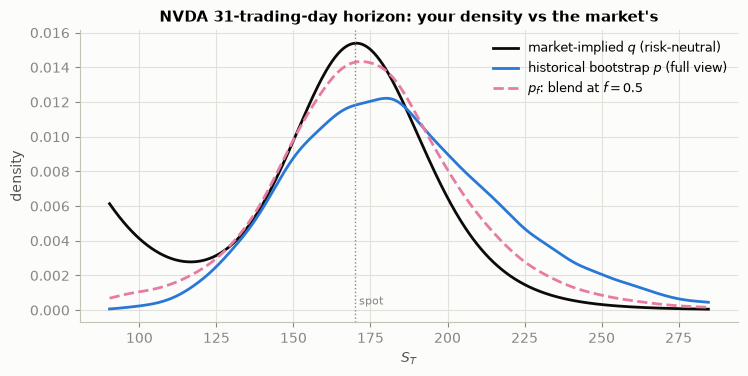

KL(p_f || q) = 0.0651 nats over 31 trading days → 52.8% annualized log-growth edge if the view is right


In [3]:
hist = provider.history(TICKER, years=8)
horizon = max(int(chain.T * 252), 1)

p_full = pl.historical_view(hist, horizon, chain.spot, q.grid, block=5, seed=1)
FRACTION = 0.5                        # half-Kelly conviction
p_view = pl.geometric_blend(p_full, q.pdf, q.grid, f=FRACTION)

fig, ax = plt.subplots()
ax.plot(q.grid, q.pdf, color=INK, label="market-implied $q$ (risk-neutral)")
ax.plot(q.grid, p_full, color=BLUE, label="historical bootstrap $p$ (full view)")
ax.plot(q.grid, p_view, color=MAGENTA, ls="--", label=f"$p_f$: blend at $f={FRACTION}$")
ax.axvline(chain.spot, color=MUT, lw=1, ls=":")
ax.text(chain.spot, ax.get_ylim()[1]*0.02, " spot", color=MUT, fontsize=8)
ax.set_xlabel("$S_T$"); ax.set_ylabel("density")
ax.set_title(f"{TICKER} {horizon*5//5}-trading-day horizon: your density vs the market's")
ax.legend(fontsize=9); plt.show()

kl = np.trapezoid(p_view * np.log(np.maximum(p_view,1e-300)/np.maximum(q.pdf,1e-300)), q.grid)
print(f"KL(p_f || q) = {kl:.4f} nats over {horizon} trading days "
      f"→ {kl/chain.T:.1%} annualized log-growth edge if the view is right")

The historical density sits right of the risk-neutral one (the drift gap)
with a fatter left tail (real crash frequency vs. lognormal-ish decay) — both disagreements
are tradable, and the optimal payoff will monetize *each* of them.

## 3 · The log-optimal payoff and its replication

$g^* = \frac{W}{Z}\frac{p_f}{q}$, with the tail ratio capped (payouts where no strikes trade
are unbuyable), then replicated on the **listed strikes actually quoted** by the exact
piecewise-linear decomposition: hold $g(K_0)$ in zero-coupon bonds and
$\Delta\text{slope}_i$ calls at each strike $K_i$ — the discrete form of
$g(S)=g(0)+g'(0)S+\int (S-K)^+ g''(K)\,dK$. Strikes with sub-\$0.10 mids are dropped and the
payoff is pre-smoothed by one strike-width so bootstrap wiggle doesn't become fake butterfly
positions.

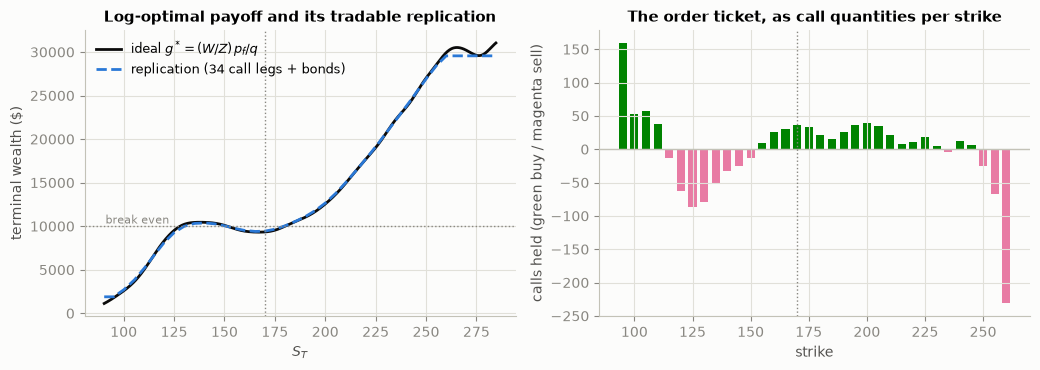

In [4]:
g = pl.log_optimal_payout(q.grid, p_view, q.pdf, wealth=WEALTH, Z=chain.Z, ratio_cap=8)
ticket = pl.replicate(q.grid, g, chain)
h = ticket.payoff(q.grid)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
ax = axes[0]
ax.plot(q.grid, g, color=INK, label="ideal $g^*=(W/Z)\,p_f/q$")
ax.plot(q.grid, h, color=BLUE, ls="--", label=f"replication ({len(ticket.legs)} call legs + bonds)")
ax.axhline(WEALTH, color=MUT, lw=1, ls=":"); ax.text(q.grid[2], WEALTH*1.03, "break even", color=MUT, fontsize=8)
ax.axvline(chain.spot, color=MUT, lw=1, ls=":")
ax.set_xlabel("$S_T$"); ax.set_ylabel("terminal wealth ($)")
ax.set_title("Log-optimal payoff and its tradable replication"); ax.legend(fontsize=9)

ax = axes[1]
colors = [GREEN if x >= 0 else MAGENTA for x in ticket.legs["qty"]]
ax.bar(ticket.legs["strike"], ticket.legs["qty"],
       width=0.7*np.median(np.diff(ticket.legs['strike'])), color=colors)
ax.axhline(0, color="#c3c2b7", lw=1); ax.axvline(chain.spot, color=MUT, lw=1, ls=":")
ax.set_xlabel("strike"); ax.set_ylabel("calls held (green buy / magenta sell)")
ax.set_title("The order ticket, as call quantities per strike")
plt.tight_layout(); plt.show()

Read the ticket left to right: **long deep-ITM calls** (they carry the
bond-plus-stock floor and the fat left tail your history says the market underprices),
**short the body** (you're selling the market the outcomes it rates likeliest — that's where
$q > p$), **long the right wing** (the underpriced-upside thesis). It is a short broad
butterfly plus a call-wing tilt — the direct generalization of the single butterflies in the
duality notebook, now with sizes chosen by the density ratio instead of by hand.

In [5]:
print(f"bonds (face value at expiry): ${ticket.bonds:,.0f}")
display(ticket.legs.assign(side=np.where(ticket.legs.qty>=0, "BUY", "SELL"))
        [["strike","side","qty","mid","cost"]].round(2))
summary = pl.summarize(q.grid, p_view, q.pdf, g, ticket, chain, wealth=WEALTH)
display(summary.round(4).to_frame("value"))

bonds (face value at expiry): $1,891


,strike,side,qty,mid,cost
0,95.0,BUY,159.34,75.93,12097.75
1,100.0,BUY,53.43,70.78,3782.01
2,105.0,BUY,57.40,65.71,3771.59
3,110.0,BUY,37.25,61.06,2274.51
4,115.0,SELL,-13.35,56.14,-749.23
5,120.0,SELL,-63.01,51.65,-3254.19
6,125.0,SELL,-86.57,47.16,-4082.93
7,130.0,SELL,-79.03,42.22,-3336.54
8,135.0,SELL,-52.72,37.66,-1985.33
9,140.0,SELL,-33.22,33.32,-1106.80


,value
budget W,10000.0000
replication cost,10573.0429
expected log growth (ideal),0.0701
expected log growth (replicated),0.0190
annualized (replicated),0.1543
P(lose money) under your view,0.6648
P(lose money) market-implied,0.7551
option legs,34.0000


Notes on the summary block:

- **Replication cost vs budget** — the gap is discretization + the flat-tail extension; in a
  live app you'd scale the ticket to the exact budget and show slippage vs mid.
- **P(lose money) is high under both densities.** That's not a bug: the log-optimal payoff
  under a right-shifted view loses small most of the time and wins large in the favored
  region. This is exactly why the fraction dial exists.
- The **replicated** growth is well below the **ideal** KL bound — the cost of the ratio cap,
  finite strikes, and smoothing. The gap is worth monitoring in the app as an "implementation
  efficiency" metric.

## 4 · Conviction as a dial: the Kelly fraction

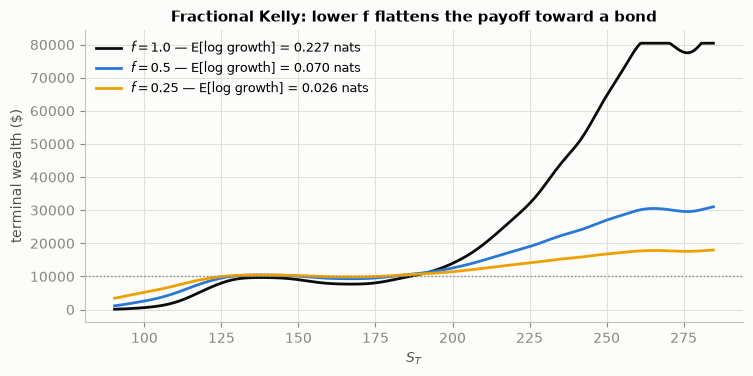

In [6]:
fig, ax = plt.subplots()
for f, c in [(1.0, INK), (0.5, BLUE), (0.25, YELLOW)]:
    pf = pl.geometric_blend(p_full, q.pdf, q.grid, f=f)
    gf = pl.log_optimal_payout(q.grid, pf, q.pdf, wealth=WEALTH, Z=chain.Z, ratio_cap=8)
    growth = pl.expected_log_growth(q.grid, pf, gf, WEALTH)
    ax.plot(q.grid, gf, color=c, label=f"$f={f}$ — E[log growth] = {growth:.3f} nats")
ax.axhline(WEALTH, color=MUT, lw=1, ls=":")
ax.set_xlabel("$S_T$"); ax.set_ylabel("terminal wealth ($)")
ax.set_title("Fractional Kelly: lower f flattens the payoff toward a bond")
ax.legend(fontsize=9); plt.show()

## 5 · From notebook to app

Everything above is a function call into `payout_lab/`, deliberately: the notebook is the
specification for a small app. The plan (full detail in **`APP_DESIGN.md`**):

- **Data**: Massive (ex-Polygon.io) REST — chain snapshot + daily aggregates — behind the
  `MassiveProvider` already in the package; set `MASSIVE_API_KEY` and this notebook re-runs on
  live quotes unchanged.
- **UI**: a small Streamlit app (ticker, expiry, Kelly fraction, drift haircut, budget) →
  density comparison, payoff, order ticket. Skeleton in `payout_app.py`.
- **Validating the thesis** (the important part): before betting on "the market undervalues
  semis," backtest it — for each month in history, extract $q$ from that day's chain, record
  the realized $S_T$, and compare log scores $\log p(S_T)$ vs $\log q(S_T)$. A persistently
  positive average difference *is* the monetizable KL edge, measured out-of-sample, per
  ticker. That backtest needs exactly one thing this environment lacks: historical option
  chains — which is the Massive subscription's job.